## Slides RL 2
- Ok I think I'm getting close on the requirements I need for the final example!
- Starting a new notebook here to really get my ducks in a row

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [4]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [5]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [6]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [7]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Some setup and baselines

In [8]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

    P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
    so the REINFORCE loop below is unchanged from the neural net version.
    """
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
        logit = feats @ self.theta         # scalar or (T,)
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [9]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

In [10]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n              
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

pi.theta=nn.Parameter(torch.tensor([0.1, 0.2]))

# optimizer = optim.Adam(pi.parameters(), lr=0.05)  # 2 params only -> larger lr than the NN version
optimizer = optim.SGD(pi.parameters(), lr=0.007)  # plain SGD: steps follow raw gradient direction (better for viz)

In [11]:
total_rewards = []

for epi in tqdm(range(500)):

    states, actions, rewards = run_rollout(seed=epi)
    # --- discounted returns-to-go: G_t = r_t + gamma * G_{t+1}, computed backwards ---
    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)
    
    # rets = (rets - rets.mean()) / (rets.std() + 1e-8)   # baseline + variance normalization

    # --- REINFORCE update: one batched forward over the whole episode ---
    state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
    action_batch = torch.tensor(actions)                              # (T,)
    prob_batch = pi(state_batch)                                      # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]             # prob of each action actually taken
    
    loss = -(torch.log(act_probs) * rets).sum()
    # loss = -(act_probs * rets).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(sum(rewards))

100%|████████████████████████████████| 500/500 [00:02<00:00, 186.33it/s]


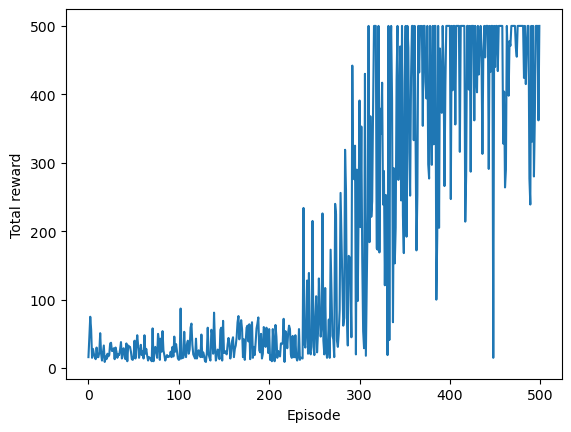

In [12]:
plt.plot(total_rewards)
plt.xlabel('Episode')
plt.ylabel('Total reward');

### 1 Stochastic Sweep 

In [13]:
# num_samples=32
# num_steps=32

# theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
# theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

# all_rewards=[]

# for t1 in tqdm(theta1_vals_viz):
#     all_rewards.append([])
#     for t2 in theta2_vals_viz:
#         all_rewards[-1].append([])
#         for i in range(num_samples):
#             pi = Pi()
#             pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
#             states, actions, rewards = run_rollout(seed=i, deterministic=False) 
#             all_rewards[-1][-1].append(np.sum(rewards).item())
# all_rewards=np.array(all_rewards)

100%|███████████████████████████████████| 32/32 [01:32<00:00,  2.88s/it]


In [119]:
# Load from disk
all_rewards = np.load(HACKIN_DIR+'/256_100_sto_2.npy')

In [120]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

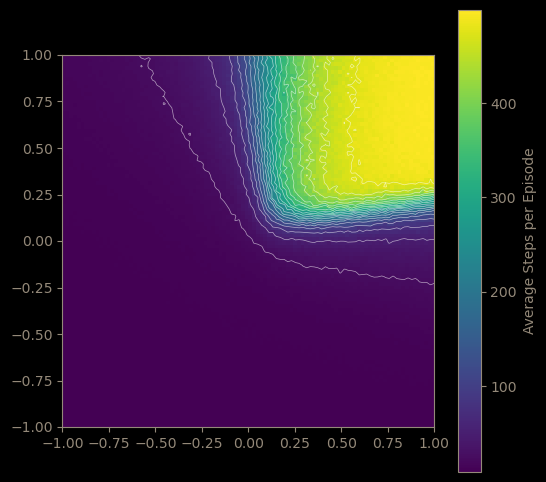

In [121]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
# plt.savefig(HACKIN_DIR+'/return_landscape_stochastic_2.png', dpi=240)

## 2. Example Hunting

- Ok, big picture here, for my approach to work I need to find a set of examples where there's a "good" trajectory with a gradient that points in the right direction
- But then the average trajectory points in the wrong direction
- And when we rescale the arrows by dividing by p, overall direction is fixed!
- I've been kinda going in circles here, sooo I think the move might be to actually just get a very simple baseline confirmed. That is:

** Does the average of the gradient log prob actually point in the right direction? **

- If that doesn't work, them I'm fucked lol
- Ok so I want to focus on just a single point in parameter space for now `0.5, -0.15`
- And then yeah if we do a bunch of rollouts from there (starting from differnt points in state space (although I would also like to try the same point later!), and compute the gradient of the log prob of the rollouts, does the arrow point in the right direction?

In [214]:
# t1, t2 = 0.5, -0.15
# t1, t2 = -0.1,-0.1 #nice grad direction
# t1, t2 = -0.2,0.3 # I think something over here could work too, good option if rollouts aren't great. Actually this is my new fav
# t1, t2 = -0.25,0.05 #Pretty nice trajectories!
# t1, t2 = -0.25, 0.00 #This kinda simplifies things nicely!
t1, t2 = -0.5, 0.00

pi = Pi()
pi.theta = nn.Parameter(torch.tensor([t1, t2]))     # set EXPLICITLY on pi itself
print('policy theta:', pi.theta.detach().numpy())

N_EPS = 1024
np.random.seed(0)
eps = []
for i in tqdm(range(N_EPS)):
    states, actions, rewards = run_rollout(seed=0, deterministic=False)  # seed=i -> same start dist as sweep
    eps.append({'obs': np.array(states), 'act': np.array(actions), 'R': float(np.sum(rewards))})
R = np.array([e['R'] for e in eps])
print(f'returns: mean {R.mean():.1f}  min {R.min():.0f}  max {R.max():.0f}')
# expect: mean ~22, max ~100-150

policy theta: [-0.5  0. ]


100%|█████████████████████████████| 1024/1024 [00:00<00:00, 1543.92it/s]

returns: mean 21.0  min 8  max 78


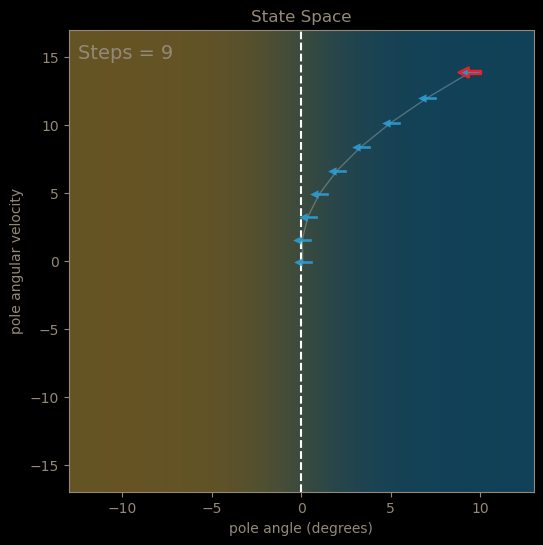

In [215]:
#Determnistic Check
states, actions, rewards = run_rollout(seed=5, deterministic=True) 

fig=plt.figure(0, (6, 6), facecolor='k')
ax=fig.add_subplot(111, facecolor='k')
obs_e, act_e = np.array(states), np.array(actions)
ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
          extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
m = act_e == 1
ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
made_it = len(act_e) == 500
ax.scatter([ang[-1]], [angvel[-1]],
           marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=260,
           facecolors='none', edgecolors=('w' if made_it else RED), linewidths=1.6, zorder=5)
ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
        ha='left', va='top', color=CHILL_BROWN, fontsize=14)
ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
ax.set_title('State Space'); style_ax(ax)



In [216]:
def grad_logP(ep, th1, th2):
    f = ep['obs'][:, 2:4].astype(np.float64)        # exactly the features Pi sees
    a = ep['act']
    p_right = 1.0 / (1.0 + np.exp(-(th1 * f[:, 0] + th2 * f[:, 1])))
    return ((a - p_right)[:, None] * f).sum(0)      # sum_t (a_t - p_t) * f_t

G = np.array([grad_logP(ep, t1, t2) for ep in eps])

# SANITY CHECK: score has zero mean IFF these probs generated these actions.
# |z| > 3 means the rollouts came from a different theta than we're differentiating at.
se = G.std(0) / np.sqrt(N_EPS)
print('mean grad logP:', G.mean(0), ' z-score:', G.mean(0) / se)

g_avg      = (R[:, None] * G).mean(0)                # REINFORCE: (1/N) sum R * grad logP
g_baseline = ((R - R.mean())[:, None] * G).mean(0)   # same expectation, ~2x less noise
unit = lambda v: v / np.linalg.norm(v)
print('avg R*grad logP        :', g_avg, ' dir', unit(g_avg))
print('avg (R-mean)*grad logP :', g_baseline, ' dir', unit(g_baseline))
# expect both ~[1.4, 1.2] -> direction ~[0.76, 0.65], i.e. up-and-right at ~40 deg

mean grad logP: [-0.00020175 -0.00085913]  z-score: [-0.03146816 -0.15429228]
avg R*grad logP        : [1.18623577 0.96700674]  dir [0.77509281 0.63184739]
avg (R-mean)*grad logP : [1.19047214 0.98504688]  dir [0.77044881 0.63750186]


In [217]:
def J_hat(th1, th2, n=1500):
    pi.theta = nn.Parameter(torch.tensor([th1, th2]))
    tot = 0.0
    for i in range(n):
        np.random.seed(100_000 + i)   # CRN: same coin sequence at every probed theta -> ~10x less FD noise
        _, _, rewards = run_rollout(seed=i, deterministic=False)
        tot += np.sum(rewards)
    return tot / n

d = 0.1
fd = np.array([(J_hat(t1+d, t2) - J_hat(t1-d, t2)) / (2*d),
               (J_hat(t1, t2+d) - J_hat(t1, t2-d)) / (2*d)])
pi.theta = nn.Parameter(torch.tensor([t1, t2]))      # restore

ang = lambda a, b: np.degrees(np.arccos(np.clip(unit(a) @ unit(b), -1, 1)))
print('FD gradient:', fd, ' dir', unit(fd))
print(f'angle to FD:  g_avg {ang(g_avg, fd):.1f} deg   g_baseline {ang(g_baseline, fd):.1f} deg')
# expect FD ~[1.3, 1.1]; in my run g_avg agreed with FD to 0.6 deg at N=4096.
# At N=1024 expect <~8 deg, at N=256 <~20 deg.

FD gradient: [1.25666667 1.61333333]  dir [0.61450468 0.78891317]
angle to FD:  g_avg 12.9 deg   g_baseline 12.5 deg


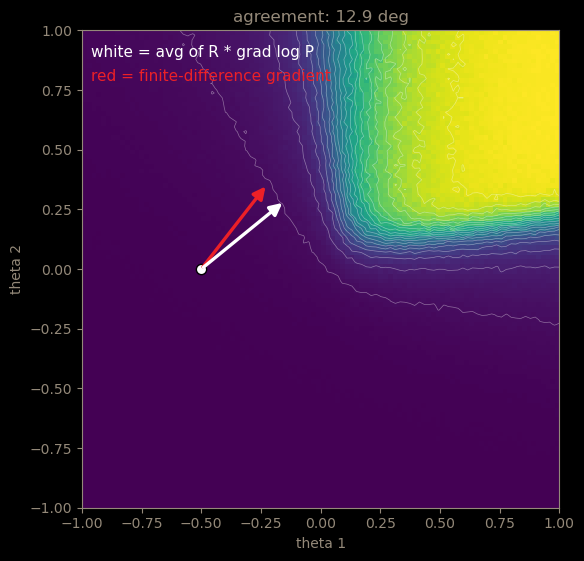

In [218]:
fig, ax = plt.subplots(figsize=(6.8, 6.2), facecolor='k'); ax.set_facecolor('k')
extent = np.radians(np.array([theta1_vals_viz[0], theta1_vals_viz[-1],
                              theta2_vals_viz[0], theta2_vals_viz[-1]]))
ax.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')
T1g, T2g = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
ax.contour(T1g, T2g, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.4)

TH = np.array([t1, t2]); L = 0.45
ax.scatter([TH[0]], [TH[1]], s=55, color='w', edgecolors='k', zorder=6)
for g, c in [(fd, RED), (g_avg, 'w')]:
    ax.annotate('', xy=TH + unit(g)*L, xytext=TH, zorder=7,
                arrowprops=dict(arrowstyle='-|>', color=c, lw=2.4, mutation_scale=18))
ax.text(0.02, 0.97, 'white = avg of R * grad log P', transform=ax.transAxes, color='w', va='top', fontsize=11)
ax.text(0.02, 0.92, 'red = finite-difference gradient', transform=ax.transAxes, color=RED, va='top', fontsize=11)
ax.set_title(f'agreement: {ang(g_avg, fd):.1f} deg', color=CHILL_BROWN)
ax.set_xlabel('theta 1'); ax.set_ylabel('theta 2'); style_ax(ax)
plt.show()

And if we lost the log?

In [219]:
# grad P(tau) = P(tau) * grad log P(tau)  -- same direction per-rollout, but now each
# rollout is weighted by its own probability. P(tau) underflows float64 for long
# rollouts, so carry logP and shift by logP.max(); this scales the whole average by
# one positive constant, leaving its direction untouched.
def logP_of(ep, th1, th2):
    f = ep['obs'][:, 2:4].astype(np.float64)
    p_right = 1.0 / (1.0 + np.exp(-(th1 * f[:, 0] + th2 * f[:, 1])))
    return np.log(np.where(ep['act'] == 1, p_right, 1.0 - p_right)).sum()

logP = np.array([logP_of(ep, t1, t2) for ep in eps])
w = np.exp(logP - logP.max())                       # P(tau) / P(most probable tau)
g_nolog = (R[:, None] * w[:, None] * G).mean(0)     # prop. to (1/N) sum R * grad P

print('logP min/max:', logP.min().round(1), logP.max().round(1))
print('no log:', g_nolog, ' dir', unit(g_nolog))
print(f'angle to FD: {ang(g_nolog, fd):.0f} deg   angle to with-log: {ang(g_nolog, g_avg):.0f} deg')

top = np.argsort(w)[::-1]
print('who dominates: top-10 most probable rollouts have lengths',
      R[top[:10]].astype(int), f'and carry {w[top[:10]].sum()/w.sum():.0%} of total weight')
# expect: no-log dir ~[-0.57, -0.82] -> ~165 deg from FD, i.e. pointing DOWNHILL,
# nearly opposite the with-log arrow. Dominated entirely by the 8-step falls.

logP min/max: -54.1 -5.4
no log: [-0.07311034 -0.06787055]  dir [-0.73288158 -0.68035622]
angle to FD: 171 deg   angle to with-log: 176 deg
who dominates: top-10 most probable rollouts have lengths [8 8 8 8 8 8 8 8 8 8] and carry 19% of total weight


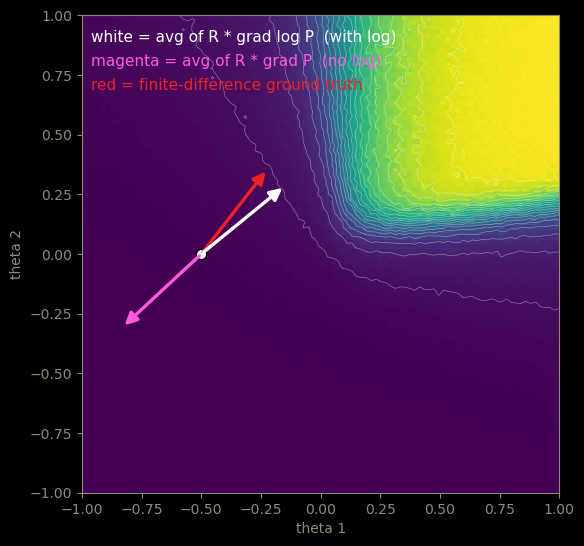

In [220]:
MAGENTA = '#ff5adf'
fig, ax = plt.subplots(figsize=(6.8, 6.2), facecolor='k'); ax.set_facecolor('k')
extent = np.radians(np.array([theta1_vals_viz[0], theta1_vals_viz[-1],
                              theta2_vals_viz[0], theta2_vals_viz[-1]]))
ax.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')
T1g, T2g = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
ax.contour(T1g, T2g, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.4)

TH = np.array([t1, t2]); L = 0.45
ax.scatter([TH[0]], [TH[1]], s=55, color='w', edgecolors='k', zorder=6)
for g, c in [(fd, RED), (g_avg, 'w'), (g_nolog, MAGENTA)]:
    ax.annotate('', xy=TH + unit(g)*L, xytext=TH, zorder=7,
                arrowprops=dict(arrowstyle='-|>', color=c, lw=2.4, mutation_scale=18))
ax.text(0.02, 0.97, 'white = avg of R * grad log P  (with log)', transform=ax.transAxes, color='w', va='top', fontsize=11)
ax.text(0.02, 0.92, 'magenta = avg of R * grad P  (no log)', transform=ax.transAxes, color=MAGENTA, va='top', fontsize=11)
ax.text(0.02, 0.87, 'red = finite-difference ground truth', transform=ax.transAxes, color=RED, va='top', fontsize=11)
ax.set_xlabel('theta 1'); ax.set_ylabel('theta 2'); style_ax(ax)
plt.show()

- Oh wow if that' correct then that's pretty good!
- Ok, so starting closer to 0,0 seems like it's going to make the gradient plot nicer.
- -0.1, -0.1 is kinda nice, seems find with the cliff argument/symmetry too.
- Ok next question, does a "good rollout" point in the right direction without the log??

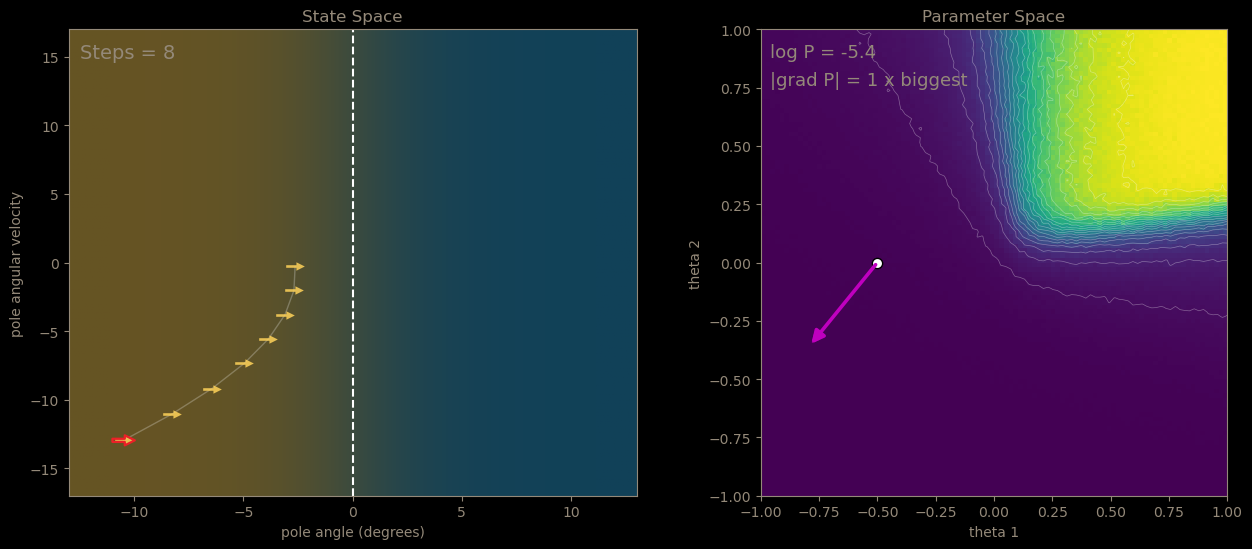

In [221]:
import os
import matplotlib as mpl

# per-rollout no-log gradient: grad P(tau_k) = P(tau_k) * grad logP(tau_k), carried as
# w_k * G_k with w_k = exp(logP_k - logP.max()) -> magnitudes relative to the most
# probable rollout (true scale differs only by one positive constant)
gradP_rel = w[:, None] * G
gradP_mag = np.linalg.norm(gradP_rel, axis=1)
MAG_MAX   = gradP_mag.max()

LEN_NORM = mpl.colors.Normalize(vmin=R.min(), vmax=R.max())
VIRIDIS  = plt.get_cmap('viridis')

def draw_traj_panel(ax, ep):
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
    m = act_e == 1
    ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
    made_it = len(act_e) == 500
    ax.scatter([ang[-1]], [angvel[-1]],
               marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=260,
               facecolors='none', edgecolors=('w' if made_it else RED), linewidths=1.6, zorder=5)
    ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
            ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
    ax.set_title('State Space'); style_ax(ax)

L_ARROW = 0.46
def draw_gradP_panel(ax, k):
    extent = np.radians(np.array([theta1_vals_viz[0], theta1_vals_viz[-1],
                                  theta2_vals_viz[0], theta2_vals_viz[-1]]))
    ax.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')
    T1g, T2g = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
    ax.contour(T1g, T2g, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.35)
    THp = np.array([t1, t2])
    ax.scatter([THp[0]], [THp[1]], s=55, color='w', edgecolors='k', zorder=6)
    d = unit(gradP_rel[k]); c = VIRIDIS(float(LEN_NORM(R[k])))
    ax.annotate('', xy=THp + d*L_ARROW, xytext=THp, zorder=6,          # direction (dashed)
                arrowprops=dict(arrowstyle='-|>', color='m', lw=1.2, ls='--', alpha=0.6, mutation_scale=12))
    rel = gradP_mag[k] / MAG_MAX
    if rel > 1e-3:                                                     # true relative length (solid)
        ax.annotate('', xy=THp + d*L_ARROW*rel, xytext=THp, zorder=7,
                    arrowprops=dict(arrowstyle='-|>', color='m', lw=2.6, mutation_scale=18))
    ax.text(0.02, 0.97, f'log P = {logP[k]:.1f}', transform=ax.transAxes,
            color=CHILL_BROWN, fontsize=13, va='top')
    ax.text(0.02, 0.91, f'|grad P| = {rel:.2g} x biggest', transform=ax.transAxes,
            color=CHILL_BROWN, fontsize=13, va='top')
    ax.set_xlabel('theta 1'); ax.set_ylabel('theta 2')
    ax.set_title('Parameter Space'); style_ax(ax)

# ---- preview one rollout ----
k = int(np.argmax(w))     # most probable (shortest); try int(np.argmax(R)) for the longest
# k=int(np.argmax(R))
# k=1
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
for ax in axes: ax.set_facecolor('k')
draw_traj_panel(axes[0], eps[k])
draw_gradP_panel(axes[1], k)
fig.tight_layout(); plt.show()

In [ ]:
save_dir = HACKIN_DIR + '/example_hunting_1/gradP_per_rollout_2'
os.makedirs(save_dir, exist_ok=True)

N_FRAMES = 128
order = np.argsort(R)                    # short -> long: watch the arrow shrink as episodes improve
frame_ids = order[np.linspace(0, len(order)-1, N_FRAMES).astype(int)]
# frame_ids = np.arange(N_FRAMES)        # or: raw sampling order instead

for out_i, k in enumerate(tqdm(frame_ids, desc='gradP frames')):
    k = int(k)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    for ax in axes: ax.set_facecolor('k')
    draw_traj_panel(axes[0], eps[k])
    draw_gradP_panel(axes[1], k)
    fig.tight_layout()
    fig.savefig(save_dir + '/' + str(out_i).zfill(4) + '.png', dpi=240, facecolor='k')
    plt.close(fig)
print(len(frame_ids), 'frames ->', save_dir)

gradP frames:  85%|████████████████▏  | 109/128 [00:38<00:06,  2.82it/s]